# 06 — LightGBM Walk-Forward Strategy

Replaces the per-session OLS with a **binary LightGBM classifier** trained on a 20-day rolling window.

**Motivation from OLS failures (notebook 04)**
- Coefficient sign instability (CTT_raw: 58 positive vs 59 negative days)
- Near-singular design matrix when autocorrelated features are added (Attempt 4 Sharpe → -7.9)
- Linear model cannot capture the VOI × LDistance_diff interaction identified in notebook 03

**Signal convention**: `lgbm_signal = P(up) − 0.5 ∈ [−0.5, 0.5]`  
This plugs directly into `run_day_simulation`: long when signal ≥ threshold, short when signal ≤ −threshold.

**New features vs OLS Strategy B**: adds `LDiff_t0` (LDistance_diff) and `CostToTrade` → 15 features total.

In [1]:
# Section 0 — Setup
import sys, os, pathlib, warnings
warnings.filterwarnings('ignore')

ROOT = pathlib.Path().resolve().parent
os.chdir(ROOT)
for p in [str(ROOT), str(ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from tqdm.auto import tqdm

import load_data
from data_utils import load_clean_main_contract
from backtest_engine import (
    run_day_simulation, compute_performance_metrics,
    run_backtest, run_parameter_sweep,
)

load_data.DB_PATH = pathlib.Path('data/market_data_2018.db')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('lightgbm', lgb.__version__)
print('Setup OK. ROOT:', ROOT)

lightgbm 4.6.0
Setup OK. ROOT: D:\Order Imbalance Research


## Section 1 — Data Loading & Signal Engineering

In [2]:
# 1.1  Load 5-level book data
COLUMNS = [
    'InstruID', 'TradDay', 'ActionDateTime',
    'BidPrice1', 'BidVolume1', 'BidPrice2', 'BidVolume2',
    'BidPrice3', 'BidVolume3', 'BidPrice4', 'BidVolume4',
    'BidPrice5', 'BidVolume5',
    'AskPrice1', 'AskVolume1', 'AskPrice2', 'AskVolume2',
    'AskPrice3', 'AskVolume3', 'AskPrice4', 'AskVolume4',
    'AskPrice5', 'AskVolume5',
    'Volume', 'Turnover', 'OpenInt',
]

df_main = load_clean_main_contract(
    start_date=20180102, end_date=20180629,
    columns=COLUMNS, db_path='data/market_data_2018.db',
)
print(f'df_main: {len(df_main):,} rows, {df_main["TradDay"].nunique()} trading days')
print(df_main.dtypes[['MidPrice', 'Spread', 'BidVolume1', 'AskVolume1']].to_string())

df_main: 2,483,302 rows, 118 trading days
MidPrice      float32
Spread        float32
BidVolume1      int32
AskVolume1      int32


In [3]:
# 1.2  VOI, OIR, MPB  (identical to notebook 04)
def compute_VOI(df):
    bid_p, bid_v = df['BidPrice1'], df['BidVolume1']
    ask_p, ask_v = df['AskPrice1'], df['AskVolume1']
    d_bid_p = bid_p.diff()
    d_ask_p = ask_p.diff()
    subtract_bid = bid_v.shift(1).where(d_bid_p == 0, other=0.0)
    delta_VB     = (bid_v - subtract_bid) * (d_bid_p >= 0)
    subtract_ask = ask_v.shift(1).where(d_ask_p == 0, other=0.0)
    delta_VA     = (ask_v - subtract_ask) * (d_ask_p <= 0)
    voi = (delta_VB - delta_VA).rename('VOI')
    voi.iloc[0] = np.nan
    return voi

def compute_MPB(df):
    mid      = df['MidPrice']
    d_vol    = df['Volume'].diff()
    d_to     = df['Turnover'].diff()
    avg_trade = (d_to / d_vol / 300).replace([np.inf, -np.inf], np.nan)
    avg_trade = avg_trade.ffill().bfill()
    roll_mid  = mid.rolling(2).mean().fillna(mid.iloc[0])
    return (avg_trade - roll_mid).rename('MPB')

df_main['VOI'] = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(compute_VOI)
)
df_main['OIR'] = (
    (df_main['BidVolume1'] - df_main['AskVolume1']) /
    (df_main['BidVolume1'] + df_main['AskVolume1'])
)
df_main['MPB'] = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(compute_MPB)
)
print(f'VOI NaN: {df_main["VOI"].isna().sum()} | OIR NaN: {df_main["OIR"].isna().sum()} | MPB NaN: {df_main["MPB"].isna().sum()}')

VOI NaN: 236 | OIR NaN: 0 | MPB NaN: 0


In [4]:
# 1.3  CostToTrade (5-lot book walk) + LDistance_diff  (new features vs OLS)
TARGET_VOLUME = 5

_bv  = df_main[['BidVolume1','BidVolume2','BidVolume3','BidVolume4','BidVolume5']].values
_bp  = df_main[['BidPrice1', 'BidPrice2', 'BidPrice3', 'BidPrice4', 'BidPrice5']].values
_av  = df_main[['AskVolume1','AskVolume2','AskVolume3','AskVolume4','AskVolume5']].values
_ap  = df_main[['AskPrice1', 'AskPrice2', 'AskPrice3', 'AskPrice4', 'AskPrice5']].values
_mid = df_main['MidPrice'].values

def _walk_book(vols, prices, target):
    cum   = np.clip(np.cumsum(vols, axis=1), 0, target)
    prev  = np.concatenate([np.zeros((len(vols), 1)), cum[:, :-1]], axis=1)
    cost  = ((cum - prev) * prices).sum(axis=1)
    return np.where(cum[:, -1] >= target, cost / target, np.nan)

avg_buy  = _walk_book(_av, _ap, TARGET_VOLUME)
avg_sell = _walk_book(_bv, _bp, TARGET_VOLUME)
df_main['CostToTrade'] = ((avg_buy / _mid - 1) + (1 - avg_sell / _mid)) / 2

# LDistance_diff: volume-weighted mean ask-distance minus bid-distance from mid
_mid_c    = _mid.reshape(-1, 1)
total_bv  = _bv.sum(axis=1)
total_av  = _av.sum(axis=1)
ld_bid    = np.where(total_bv > 0, ((_mid_c - _bp) * _bv).sum(axis=1) / total_bv, np.nan)
ld_ask    = np.where(total_av > 0, ((_ap - _mid_c) * _av).sum(axis=1) / total_av, np.nan)
df_main['LDistance_diff'] = ld_ask - ld_bid

print(f'CostToTrade NaN: {df_main["CostToTrade"].isna().sum()}')
print(f'LDistance_diff NaN: {df_main["LDistance_diff"].isna().sum()}')
print(f'CostToTrade mean: {df_main["CostToTrade"].mean():.6f}')
print(f'LDistance_diff mean: {df_main["LDistance_diff"].mean():.4f}')

CostToTrade NaN: 0
LDistance_diff NaN: 0
CostToTrade mean: 0.000209
LDistance_diff mean: 0.0203


## Section 2 — Feature Matrix and Classification Target

In [5]:
# 2.1  Build 15-feature matrix (13 OLS features + LDiff_t0 + CostToTrade)
L_B = 5
k_B = 20   # holding horizon: 20-tick rolling mean target

FEATURE_COLS_OLS  = [f'VOI_t{j}' for j in range(L_B + 1)] + \
                    [f'OIR_t{j}' for j in range(L_B + 1)] + ['MPB_t0']
FEATURE_COLS_LGBM = FEATURE_COLS_OLS + ['LDiff_t0', 'CostToTrade']
assert len(FEATURE_COLS_OLS)  == 13
assert len(FEATURE_COLS_LGBM) == 15

DAY_COL      = 'TradDay'
SESSION_COL  = 'session'
BID_COL      = 'BidPrice1'
ASK_COL      = 'AskPrice1'
TIME_COL     = 'time_seconds'
TARGET_CONT  = 'y'
TARGET_CLASS = 'y_class'

def build_feature_matrix_lgbm(df, L=L_B, k=k_B):
    n      = len(df)
    spread = df['Spread']
    voi    = df['VOI']
    oir    = df['OIR']
    data   = {}
    for j in range(L + 1):
        data[f'VOI_t{j}'] = voi.shift(j) / spread
        data[f'OIR_t{j}'] = oir.shift(j) / spread
    data['MPB_t0']      = df['MPB'] / spread
    data['LDiff_t0']    = df['LDistance_diff']
    data['CostToTrade'] = df['CostToTrade']
    data['y']           = df['MidPrice'].rolling(k).mean().shift(-k) - df['MidPrice']
    out = pd.DataFrame(data, index=df.index).iloc[L + 1 : n - k].copy()
    out['y_class'] = (out['y'] > 0).astype(np.int8)
    return out

all_features = (
    df_main.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(build_feature_matrix_lgbm)
    .join(df_main[[DAY_COL, SESSION_COL, BID_COL, ASK_COL, 'MidPrice', TIME_COL]])
    .reset_index(drop=True)
)

print(f'all_features: {len(all_features):,} rows, {all_features.columns.tolist()}')
print(f'NaN in feature cols: {all_features[FEATURE_COLS_LGBM].isna().sum().sum()}')
print(f'NaN in target:       {all_features[[TARGET_CONT, TARGET_CLASS]].isna().sum().to_dict()}')

all_features: 2,477,166 rows, ['VOI_t0', 'OIR_t0', 'VOI_t1', 'OIR_t1', 'VOI_t2', 'OIR_t2', 'VOI_t3', 'OIR_t3', 'VOI_t4', 'OIR_t4', 'VOI_t5', 'OIR_t5', 'MPB_t0', 'LDiff_t0', 'CostToTrade', 'y', 'y_class', 'TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']
NaN in feature cols: 0
NaN in target:       {'y': 0, 'y_class': 0}


In [6]:
# 2.2  Class balance check
vc = all_features[TARGET_CLASS].value_counts().sort_index()
print('y_class distribution:')
for cls, cnt in vc.items():
    print(f'  class {cls}: {cnt:,} ({cnt/len(all_features)*100:.1f}%)')

# Cross-check: y=0 exact cases
n_exact_zero = (all_features[TARGET_CONT] == 0).sum()
print(f'Exact y=0: {n_exact_zero:,} ({n_exact_zero/len(all_features)*100:.1f}%) -- lumped into class 0')

y_class distribution:
  class 0: 1,266,575 (51.1%)
  class 1: 1,210,591 (48.9%)
Exact y=0: 711 (0.0%) -- lumped into class 0


## Section 3 — Walk-Forward LightGBM Training

For each test day `d` (starting from day 21): train on the 20 preceding days, predict `P(up)` for day `d`.  
All 15 features are used; `is_unbalance=True` handles the class skew observed in 2.2.

In [7]:
# 3.1  Constants + LGBM hyperparameters
CONTRACT_MULT = 300
TR_COST_OPEN  = 2.3e-5
TR_COST_CLOSE = 2.3e-4

TRADING_HOURS = {
    'morning':   {'open': 9*3600+16*60, 'close': 11*3600+20*60, 'end': 11*3600+28*60},
    'afternoon': {'open': 13*3600+1*60, 'close': 15*3600+0*60,  'end': 15*3600+13*60},
}

TRAIN_WINDOW = 20
ALL_DAYS     = sorted(all_features[DAY_COL].unique().tolist())
LGBM_TEST_DAYS = ALL_DAYS[TRAIN_WINDOW:]

LGBM_PARAMS = {
    'n_estimators':      300,
    'max_depth':           5,
    'learning_rate':    0.05,
    'num_leaves':         31,
    'min_child_samples': 200,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'is_unbalance':     True,
    'verbose':            -1,
    'n_jobs':             -1,
    'random_state':       42,
}

print(f'Total days: {len(ALL_DAYS)} | Warm-up: {TRAIN_WINDOW} | Test days: {len(LGBM_TEST_DAYS)}')
print(f'Test period: {LGBM_TEST_DAYS[0]} to {LGBM_TEST_DAYS[-1]}')

Total days: 118 | Warm-up: 20 | Test days: 98
Test period: 20180131 to 20180629


In [8]:
# 3.2  Walk-forward training loop
all_features['lgbm_prob']   = np.nan
all_features['lgbm_signal'] = np.nan
feature_importances = []

for i, test_day in enumerate(tqdm(ALL_DAYS, desc='Walk-forward')):
    if i < TRAIN_WINDOW:
        continue

    train_days = set(ALL_DAYS[i - TRAIN_WINDOW : i])
    train_mask = all_features[DAY_COL].isin(train_days)
    train_df   = all_features[train_mask].dropna(subset=FEATURE_COLS_LGBM + [TARGET_CLASS])
    if len(train_df) < 1000:
        continue

    X_train = train_df[FEATURE_COLS_LGBM].values
    y_train = train_df[TARGET_CLASS].values

    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(X_train, y_train)
    feature_importances.append(model.feature_importances_)

    test_mask  = all_features[DAY_COL] == test_day
    test_df    = all_features[test_mask]
    valid      = test_df[FEATURE_COLS_LGBM].notna().all(axis=1)
    proba      = np.full(len(test_df), np.nan)
    if valid.any():
        proba[valid.values] = model.predict_proba(test_df.loc[valid, FEATURE_COLS_LGBM].values)[:, 1]

    all_features.loc[test_mask, 'lgbm_prob']   = proba
    all_features.loc[test_mask, 'lgbm_signal'] = proba - 0.5

coverage = all_features.loc[all_features[DAY_COL].isin(LGBM_TEST_DAYS), 'lgbm_prob'].notna().mean()
print(f'Walk-forward complete. Signal coverage on test days: {coverage:.1%}')

Walk-forward:   0%|          | 0/118 [00:00<?, ?it/s]

Walk-forward: 100%|██████████| 118/118 [03:18<00:00,  1.68s/it]

Walk-forward complete. Signal coverage on test days: 100.0%


## Section 4 — Signal Quality & Feature Importance

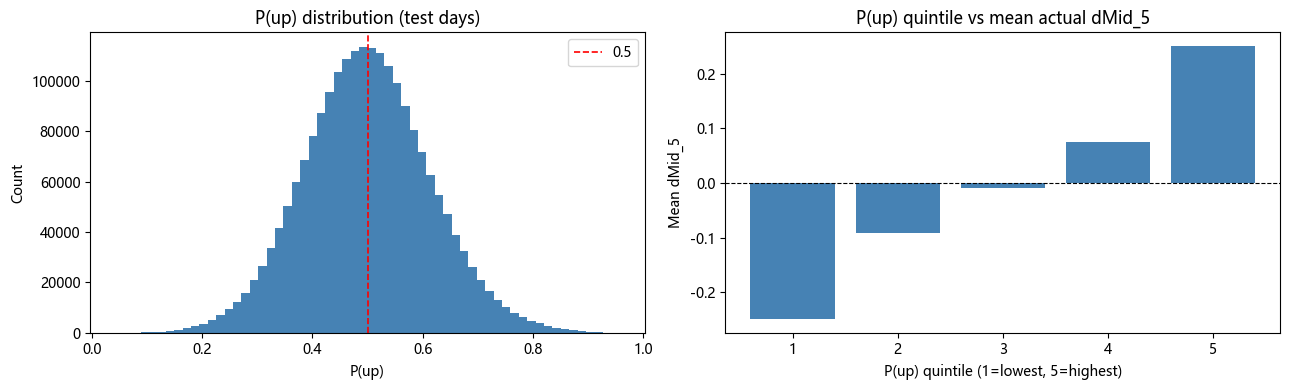

P(up) quintile vs mean actual return:
prob_q
1   -0.2491
2   -0.0924
3   -0.0085
4    0.0745
5    0.2510


In [9]:
# 4.1  P(up) distribution and quintile conditional return
test_mask = all_features[DAY_COL].isin(LGBM_TEST_DAYS)
test_df   = all_features[test_mask].dropna(subset=['lgbm_prob', TARGET_CONT])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: P(up) histogram
axes[0].hist(test_df['lgbm_prob'], bins=60, color='steelblue', edgecolor='none')
axes[0].axvline(0.5, color='red', linewidth=1.2, linestyle='--', label='0.5')
axes[0].set_title('P(up) distribution (test days)')
axes[0].set_xlabel('P(up)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: P(up) quintile vs actual future mid-price change
test_df = test_df.copy()
test_df['prob_q'] = pd.qcut(test_df['lgbm_prob'], 5, labels=False) + 1
q_means = test_df.groupby('prob_q')[TARGET_CONT].mean()
axes[1].bar(q_means.index, q_means.values, color='steelblue')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('P(up) quintile vs mean actual dMid_5')
axes[1].set_xlabel('P(up) quintile (1=lowest, 5=highest)')
axes[1].set_ylabel('Mean dMid_5')

plt.tight_layout()
plt.show()

print('P(up) quintile vs mean actual return:')
print(q_means.to_string(float_format='{:.4f}'.format))

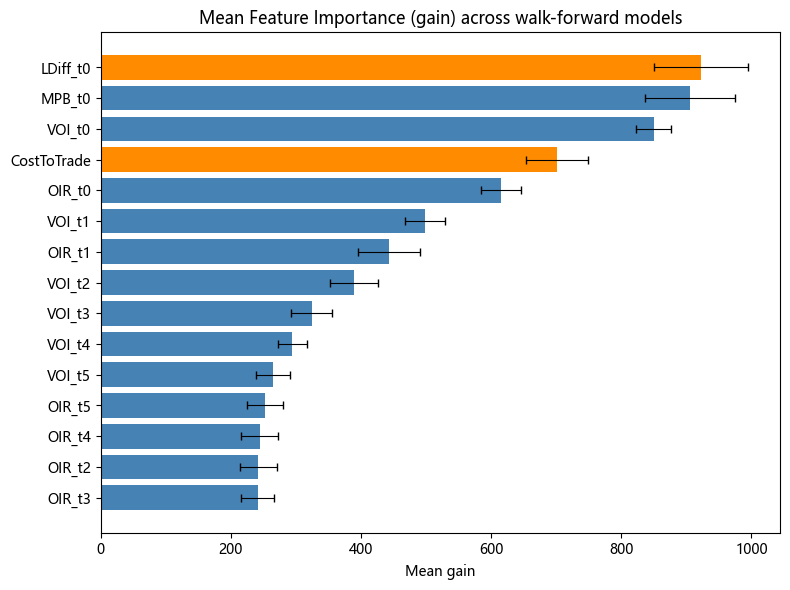

Feature importance (sorted by mean gain):
    feature  mean_gain  std_gain
   LDiff_t0      922.4      71.8
     MPB_t0      905.9      69.4
     VOI_t0      849.6      26.5
CostToTrade      700.9      47.5
     OIR_t0      615.4      30.4
     VOI_t1      498.9      30.9
     OIR_t1      443.0      47.0
     VOI_t2      389.4      37.1
     VOI_t3      324.2      31.2
     VOI_t4      294.8      22.7
     VOI_t5      264.7      26.1
     OIR_t5      252.0      27.7
     OIR_t4      244.3      28.9
     OIR_t2      242.4      27.9
     OIR_t3      241.8      25.3


In [10]:
# 4.2  Feature importance (average gain across all walk-forward models)
importance_arr = np.array(feature_importances)
mean_imp = importance_arr.mean(axis=0)
std_imp  = importance_arr.std(axis=0)

imp_df = pd.DataFrame({
    'feature':   FEATURE_COLS_LGBM,
    'mean_gain': mean_imp,
    'std_gain':  std_imp,
}).sort_values('mean_gain', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['darkorange' if f in ['LDiff_t0', 'CostToTrade'] else 'steelblue' for f in imp_df['feature']]
ax.barh(imp_df['feature'], imp_df['mean_gain'], xerr=imp_df['std_gain'],
        color=colors, capsize=3, error_kw={'linewidth': 0.8})
ax.set_title('Mean Feature Importance (gain) across walk-forward models')
ax.set_xlabel('Mean gain')
plt.tight_layout()
plt.show()

print('Feature importance (sorted by mean gain):')
print(imp_df.sort_values('mean_gain', ascending=False).to_string(index=False, float_format='{:.1f}'.format))

## Section 5 — Backtest: LGBM Signal → Trades

Signal = `P(up) − 0.5`. Entry convention matches `run_day_simulation`:
- Long when signal ≥ threshold  (i.e., P(up) ≥ 0.5 + threshold)
- Short when signal ≤ −threshold (i.e., P(up) ≤ 0.5 − threshold)

Threshold sweep maps threshold → minimum confidence gap above 50%.

In [11]:
# 5.1  Backtest runner (builds results dict matching backtest_engine format)
def run_lgbm_backtest(df, signal_col, test_days, threshold):
    results = {}
    for day in test_days:
        day_res = {
            'r_squared':            0.0,
            'coefs':                None,
            'daily_pnl':            0.0,
            'daily_trade_volume':   0,
            'daily_trade_pnl_list': [],
        }
        for session in ['morning', 'afternoon']:
            mask    = (df[DAY_COL] == day) & (df[SESSION_COL] == session)
            sess_df = df[mask]
            if len(sess_df) == 0:
                continue
            sess_res = run_day_simulation(
                signals=sess_df[signal_col].values,
                bid_prices=sess_df[BID_COL].values,
                ask_prices=sess_df[ASK_COL].values,
                time_seconds=sess_df[TIME_COL].values,
                threshold=threshold,
                tr_cost_open=TR_COST_OPEN,
                tr_cost_close=TR_COST_CLOSE,
                contract_multiplier=CONTRACT_MULT,
                trading_hours=TRADING_HOURS[session],
            )
            day_res[session]               = sess_res
            day_res['daily_pnl']          += sum(sess_res['trade_pnl_list'])
            day_res['daily_trade_volume'] += sess_res['trade_volume']
            day_res['daily_trade_pnl_list'].extend(sess_res['trade_pnl_list'])
        results[day] = day_res
    return results

print('run_lgbm_backtest defined.')

run_lgbm_backtest defined.


In [12]:
# 5.2  Threshold sweep
THRESHOLDS = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
lgbm_sweep_rows = []

for thr in THRESHOLDS:
    res = run_lgbm_backtest(all_features, 'lgbm_signal', LGBM_TEST_DAYS, thr)
    m   = compute_performance_metrics(
        res, trading_days=LGBM_TEST_DAYS, verbose=False, output_dir=None
    )
    lgbm_sweep_rows.append({
        'threshold':     thr,
        'P_min':         round(0.5 + thr, 3),
        'sharpe':        m['annualized_sharpe'],
        'mean_pnl':      m['mean_daily_pnl'],
        'win_rate':      m['win_rate_per_trade'],
        'n_trades':      m['n_trades'],
        'days_profit':   m['days_with_profit'],
        'days_total':    m['n_days'],
    })
    print(f'thr={thr:.3f} P>{0.5+thr:.3f} | Sharpe={m["annualized_sharpe"]:+.3f} '
          f'| PnL={m["mean_daily_pnl"]:+,.0f} | trades={m["n_trades"]:,} '
          f'| win={m["win_rate_per_trade"]*100:.1f}%')

lgbm_sweep = pd.DataFrame(lgbm_sweep_rows)
print('\nLGBM threshold sweep complete.')

thr=0.005 P>0.505 | Sharpe=-118.357 | PnL=-2,288,940 | trades=493,454 | win=2.5%
thr=0.010 P>0.510 | Sharpe=-118.170 | PnL=-2,109,986 | trades=461,185 | win=2.7%
thr=0.020 P>0.520 | Sharpe=-118.652 | PnL=-1,804,199 | trades=405,387 | win=3.3%
thr=0.030 P>0.530 | Sharpe=-119.100 | PnL=-1,545,873 | trades=357,602 | win=4.0%
thr=0.050 P>0.550 | Sharpe=-122.766 | PnL=-1,139,038 | trades=280,716 | win=5.6%
thr=0.080 P>0.580 | Sharpe=-128.905 | PnL=-713,859 | trades=196,666 | win=9.1%
thr=0.100 P>0.600 | Sharpe=-130.131 | PnL=-517,459 | trades=155,908 | win=12.0%
thr=0.120 P>0.620 | Sharpe=-129.861 | PnL=-371,294 | trades=123,737 | win=15.3%
thr=0.150 P>0.650 | Sharpe=-109.227 | PnL=-210,865 | trades=85,706 | win=21.7%
thr=0.200 P>0.700 | Sharpe=-44.641 | PnL=-72,046 | trades=44,670 | win=32.4%
thr=0.250 P>0.750 | Sharpe=-12.808 | PnL=-15,771 | trades=20,570 | win=41.8%
thr=0.300 P>0.800 | Sharpe=-0.738 | PnL=-712 | trades=7,647 | win=46.7%
thr=0.350 P>0.850 | Sharpe=+2.599 | PnL=+1,942 | tr

In [13]:
# 5.3  Best LGBM threshold — detail
best_idx = lgbm_sweep['sharpe'].idxmax()
best_thr = lgbm_sweep.loc[best_idx, 'threshold']

best_res = run_lgbm_backtest(all_features, 'lgbm_signal', LGBM_TEST_DAYS, best_thr)
print(f'--- LGBM best threshold = {best_thr} (P(up) > {0.5+best_thr:.2f}) ---')
best_metrics_lgbm = compute_performance_metrics(
    best_res, trading_days=LGBM_TEST_DAYS, verbose=True, output_dir=None
)

--- LGBM best threshold = 0.35 (P(up) > 0.85) ---
Performance Summary
  Trading days              : 98
  Total round-trips         : 1874
  Mean daily PnL (CNY)      :     1,942.22
  Std daily PnL             :    11,861.85
  Standard error            :     1,198.23
  t-statistic               :       1.6209
  p-value (one-tailed)      :     5.41e-02
  Days with profit          :    52 / 98  (53.1%)
  Days with loss            :    46 / 98  (46.9%)
  Mean daily trade volume   :        19.12
  Avg daily Sharpe          :       0.0230
  Annualized Sharpe         :       2.5992
  Avg R-squared (training)  :       0.0000
  Win rate per trade        :       52.08%
  Max drawdown (CNY)        :    52,587.82


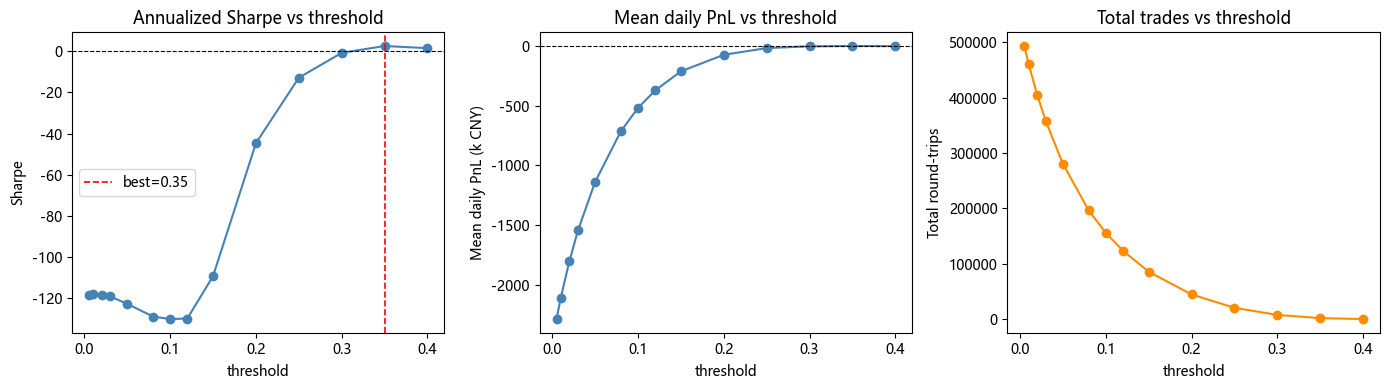

In [14]:
# 5.4  Sweep plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(lgbm_sweep['threshold'], lgbm_sweep['sharpe'], marker='o', color='steelblue')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(best_thr, color='red', linewidth=1.2, linestyle='--', label=f'best={best_thr}')
axes[0].set_title('Annualized Sharpe vs threshold')
axes[0].set_xlabel('threshold')
axes[0].set_ylabel('Sharpe')
axes[0].legend()

axes[1].plot(lgbm_sweep['threshold'], lgbm_sweep['mean_pnl'] / 1000, marker='o', color='steelblue')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Mean daily PnL vs threshold')
axes[1].set_xlabel('threshold')
axes[1].set_ylabel('Mean daily PnL (k CNY)')

axes[2].plot(lgbm_sweep['threshold'], lgbm_sweep['n_trades'], marker='o', color='darkorange')
axes[2].set_title('Total trades vs threshold')
axes[2].set_xlabel('threshold')
axes[2].set_ylabel('Total round-trips')

plt.tight_layout()
plt.show()

## Section 6 — OLS Strategy B Baseline (1-day rolling)

Run OLS with the same 13-feature set and 1-day lookback — identical to notebook 04 Strategy B — evaluated over the **same 98-day test period** to give a like-for-like comparison.

In [15]:
# 6.1  OLS sweep over the LGBM test period
OLS_THRESHOLDS = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30, 0.35, 0.40]

print('Precomputing OLS signals (1-day rolling)...')
ols_sweep = run_parameter_sweep(
    features_df=all_features,
    feature_cols=FEATURE_COLS_OLS,
    target_col=TARGET_CONT,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    q_values=OLS_THRESHOLDS,
    tr_cost_open=TR_COST_OPEN,
    tr_cost_close=TR_COST_CLOSE,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    trading_days=LGBM_TEST_DAYS,
    output_dir=None,
    label='',
)
print('OLS sweep complete.')

Precomputing OLS signals (1-day rolling)...
Precomputing signals for parameter sweep...
Signals cached for 234 (day, session) pairs.
  q=0.050  mean_daily_pnl=  -687,837  t=-60.560  sharpe=-97.113
  q=0.080  mean_daily_pnl=  -369,715  t=-48.039  sharpe=-77.034
  q=0.100  mean_daily_pnl=  -257,372  t=-41.512  sharpe=-66.567
  q=0.120  mean_daily_pnl=  -189,196  t=-36.780  sharpe=-58.980
  q=0.150  mean_daily_pnl=  -128,233  t=-32.333  sharpe=-51.849
  q=0.180  mean_daily_pnl=   -88,972  t=-26.776  sharpe=-42.937
  q=0.200  mean_daily_pnl=   -71,173  t=-23.612  sharpe=-37.863
  q=0.250  mean_daily_pnl=   -42,606  t=-16.470  sharpe=-26.411
  q=0.300  mean_daily_pnl=   -25,254  t=-12.364  sharpe=-19.827
  q=0.350  mean_daily_pnl=   -13,796  t=-7.112  sharpe=-11.405
  q=0.400  mean_daily_pnl=    -8,443  t=-4.698  sharpe=-7.534
Sweep complete.
OLS sweep complete.


In [16]:
# 6.2  Best OLS threshold detail
best_ols_idx = ols_sweep['annualized_sharpe'].idxmax()
best_ols_q   = ols_sweep.loc[best_ols_idx, 'q']

best_ols_res = run_backtest(
    features_df=all_features,
    feature_cols=FEATURE_COLS_OLS,
    target_col=TARGET_CONT,
    day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    threshold=best_ols_q,
    tr_cost_open=TR_COST_OPEN, tr_cost_close=TR_COST_CLOSE,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)
print(f'--- OLS best threshold q={best_ols_q} ---')
best_metrics_ols = compute_performance_metrics(
    best_ols_res, trading_days=LGBM_TEST_DAYS, verbose=True, output_dir=None
)

--- OLS best threshold q=0.4 ---
Performance Summary
  Trading days              : 98
  Total round-trips         : 8553
  Mean daily PnL (CNY)      :    -8,442.53
  Std daily PnL             :    17,789.45
  Standard error            :     1,797.01
  t-statistic               :      -4.6981
  p-value (one-tailed)      :     1.00e+00
  Days with profit          :    27 / 98  (27.6%)
  Days with loss            :    71 / 98  (72.4%)
  Mean daily trade volume   :        87.28
  Avg daily Sharpe          :      -0.1120
  Annualized Sharpe         :      -7.5337
  Avg R-squared (training)  :       0.0270
  Win rate per trade        :       35.43%
  Max drawdown (CNY)        :   902,775.33


In [17]:
# 6.3  Side-by-side comparison table
rows = []
for label, metrics, thr in [
    ('OLS 1-day',  best_metrics_ols,  best_ols_q),
    ('LGBM 20-day', best_metrics_lgbm, best_thr),
]:
    rows.append({
        'Strategy':        label,
        'Threshold':       thr,
        'Ann. Sharpe':     f"{metrics['annualized_sharpe']:+.3f}",
        'Mean PnL/day':    f"{metrics['mean_daily_pnl']:+,.0f}",
        'Win rate':        f"{metrics['win_rate_per_trade']*100:.1f}%",
        'Days profit':     f"{metrics['days_with_profit']}/{metrics['n_days']}",
        'Total trades':    f"{metrics['n_trades']:,}",
        'Max drawdown':    f"{metrics['max_drawdown']:,.0f}",
    })

cmp = pd.DataFrame(rows).set_index('Strategy')
print('\n=== Strategy Comparison (same test period) ===')
print(cmp.to_string())


=== Strategy Comparison (same test period) ===
             Threshold Ann. Sharpe Mean PnL/day Win rate Days profit Total trades Max drawdown
Strategy                                                                                      
OLS 1-day         0.40      -7.534       -8,443    35.4%       27/98        8,553      902,775
LGBM 20-day       0.35      +2.599       +1,942    52.1%       52/98        1,874       52,588


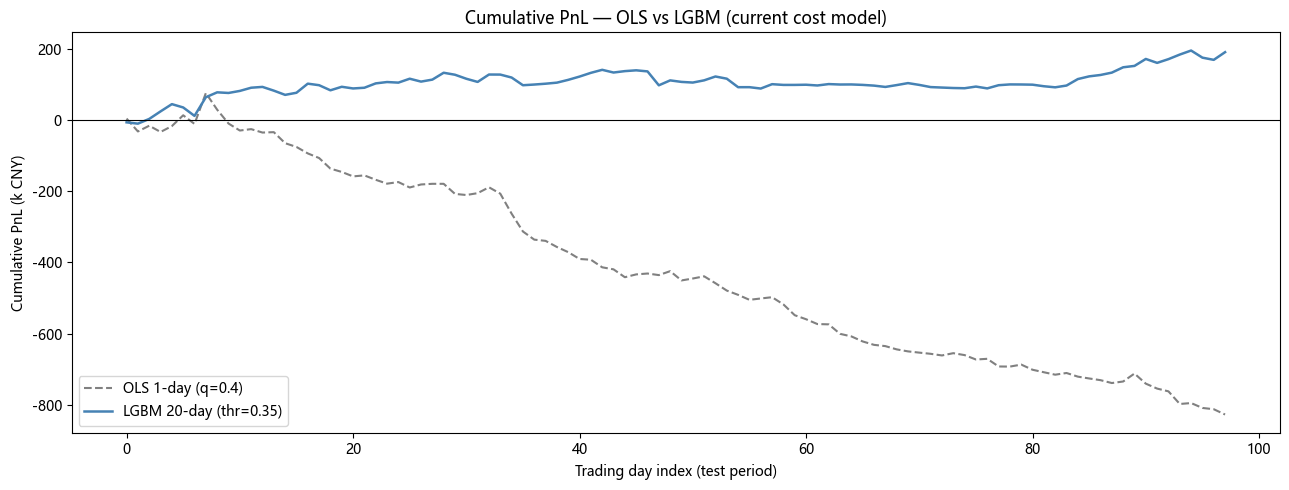

In [18]:
# 6.4  Equity curves on same axes
fig, ax = plt.subplots(figsize=(13, 5))

# OLS curve
ols_days   = sorted(d for d in best_ols_res if d in set(LGBM_TEST_DAYS))
ols_dpnl   = np.array([best_ols_res[d]['daily_pnl'] for d in ols_days])
ols_cum    = np.cumsum(ols_dpnl)
ax.plot(range(len(ols_days)), ols_cum / 1000,
        label=f'OLS 1-day (q={best_ols_q})', color='grey', linewidth=1.5, linestyle='--')

# LGBM curve
lgbm_days  = sorted(best_res.keys())
lgbm_dpnl  = np.array([best_res[d]['daily_pnl'] for d in lgbm_days])
lgbm_cum   = np.cumsum(lgbm_dpnl)
ax.plot(range(len(lgbm_days)), lgbm_cum / 1000,
        label=f'LGBM 20-day (thr={best_thr})', color='steelblue', linewidth=1.8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_title('Cumulative PnL — OLS vs LGBM (current cost model)')
ax.set_xlabel('Trading day index (test period)')
ax.set_ylabel('Cumulative PnL (k CNY)')
ax.legend()
plt.tight_layout()
plt.show()

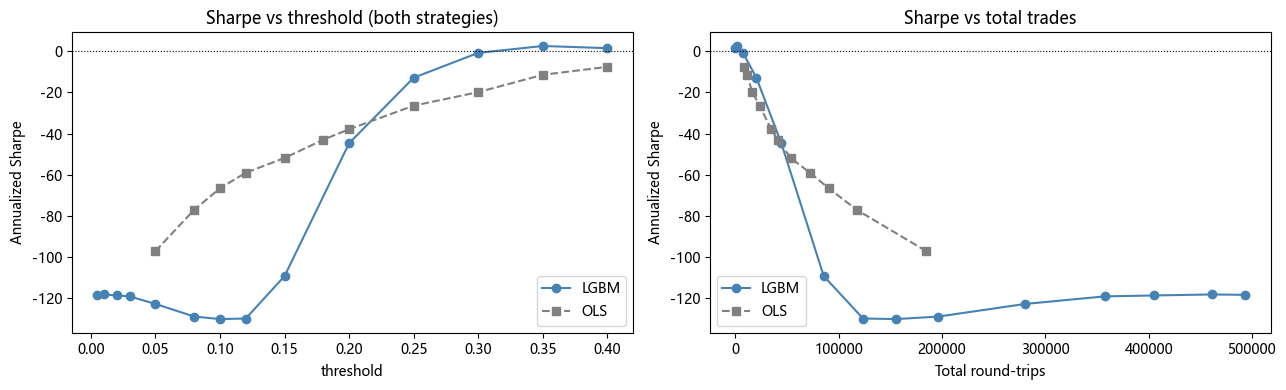

In [19]:
# 6.5  Full sweep comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(lgbm_sweep['threshold'],     lgbm_sweep['sharpe'],     marker='o', color='steelblue', label='LGBM')
axes[0].plot(ols_sweep['q'],              ols_sweep['annualized_sharpe'], marker='s', color='grey', linestyle='--', label='OLS')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[0].set_title('Sharpe vs threshold (both strategies)')
axes[0].set_xlabel('threshold')
axes[0].set_ylabel('Annualized Sharpe')
axes[0].legend()

axes[1].plot(lgbm_sweep['n_trades'],      lgbm_sweep['sharpe'],     marker='o', color='steelblue', label='LGBM')
axes[1].plot(ols_sweep['mean_daily_volume'] * len(LGBM_TEST_DAYS),
             ols_sweep['annualized_sharpe'], marker='s', color='grey', linestyle='--', label='OLS')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[1].set_title('Sharpe vs total trades')
axes[1].set_xlabel('Total round-trips')
axes[1].set_ylabel('Annualized Sharpe')
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 7 — Summary

| Dimension | OLS 1-day | LGBM 20-day |
|---|---|---|
| **Training** | Previous day (1×20K ticks) | Previous 20 days (20×20K ticks) |
| **Model** | Linear (least-squares) | Gradient-boosted trees |
| **Features** | 13 (VOI×6, OIR×6, MPB) | 15 (+LDiff_t0, +CostToTrade) |
| **Signal** | Predicted ΔMid (continuous) | P(up) − 0.5 (probability) |
| **Target** | Continuous ΔMid | Binary: sign(ΔMid) > 0 |

**What to look for in the results:**

1. **Trade count**: LGBM with high threshold (P>0.65) should show significantly fewer trades than OLS — this is the primary mechanism for surviving transaction costs.
2. **Win rate**: LGBM should show higher per-trade win rate than OLS because the probability threshold filters out marginal signals.
3. **Sharpe**: improvement depends on whether the nonlinear features (LDiff_t0 interaction with VOI) add genuine alpha beyond what the reduced trade count already gives.

**Known limitations**: The 20-day training window may lag regime changes; the binary target discards signal magnitude (a large ΔMid and a small ΔMid both become class 1). Further experiments could explore: rolling window length, 3-class target (−1/0/+1), or replacing the binary output with a regression head.

## Section 8 — Out-of-Sample Validation: 2026 Data

**Protocol**: threshold = 0.35 frozen from 2018 in-sample, never re-optimized.  
The LGBM model is seeded with the last 20 days of 2018 data, then walk-forward retrains as 2026 data arrives — exactly as it would in live deployment.

In [23]:
# reload data_utils so the format='mixed' fix takes effect without kernel restart
import importlib, data_utils as _du
importlib.reload(_du)
from data_utils import load_clean_main_contract
print('data_utils reloaded')

data_utils reloaded


In [24]:
# 8.1  Load 2026 IF data and compute same feature pipeline
df_2026 = load_clean_main_contract(
    start_date=20260202, end_date=20260508,
    columns=COLUMNS, db_path='data/market_data.db',
)
print(f'df_2026: {len(df_2026):,} rows, {df_2026["TradDay"].nunique()} trading days')
print(f'Price range: {df_2026["BidPrice1"].min():.0f} - {df_2026["BidPrice1"].max():.0f}')

df_2026['VOI'] = df_2026.groupby([DAY_COL, SESSION_COL], group_keys=False).apply(compute_VOI)
df_2026['OIR'] = ((df_2026['BidVolume1'] - df_2026['AskVolume1']) /
                  (df_2026['BidVolume1'] + df_2026['AskVolume1']))
df_2026['MPB'] = df_2026.groupby([DAY_COL, SESSION_COL], group_keys=False).apply(compute_MPB)

_bv2  = df_2026[['BidVolume1','BidVolume2','BidVolume3','BidVolume4','BidVolume5']].values
_bp2  = df_2026[['BidPrice1', 'BidPrice2', 'BidPrice3', 'BidPrice4', 'BidPrice5']].values
_av2  = df_2026[['AskVolume1','AskVolume2','AskVolume3','AskVolume4','AskVolume5']].values
_ap2  = df_2026[['AskPrice1', 'AskPrice2', 'AskPrice3', 'AskPrice4', 'AskPrice5']].values
_mid2 = df_2026['MidPrice'].values
avg_buy2  = _walk_book(_av2, _ap2, TARGET_VOLUME)
avg_sell2 = _walk_book(_bv2, _bp2, TARGET_VOLUME)
df_2026['CostToTrade'] = ((avg_buy2 / _mid2 - 1) + (1 - avg_sell2 / _mid2)) / 2
_mid2_c   = _mid2.reshape(-1, 1)
ld_bid2   = np.where(_bv2.sum(1) > 0, ((_mid2_c - _bp2) * _bv2).sum(1) / _bv2.sum(1), np.nan)
ld_ask2   = np.where(_av2.sum(1) > 0, ((_ap2 - _mid2_c) * _av2).sum(1) / _av2.sum(1), np.nan)
df_2026['LDistance_diff'] = ld_ask2 - ld_bid2

all_features_2026 = (
    df_2026.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(build_feature_matrix_lgbm)
    .join(df_2026[[DAY_COL, SESSION_COL, BID_COL, ASK_COL, 'MidPrice', TIME_COL]])
    .reset_index(drop=True)
)
ALL_DAYS_2026 = sorted(all_features_2026[DAY_COL].unique().tolist())
print(f'all_features_2026: {len(all_features_2026):,} rows, {len(ALL_DAYS_2026)} days')
print(f'NaN features: {all_features_2026[FEATURE_COLS_LGBM].isna().sum().sum()}')

df_2026: 1,559,260 rows, 59 trading days
Price range: 4307 - 4869
all_features_2026: 1,556,192 rows, 59 days
NaN features: 0


In [25]:
# 8.2  Walk-forward OOS: seed from last 20 days of 2018, threshold frozen at 0.35
OOS_THRESHOLD = 0.35

tail_2018     = all_features[all_features[DAY_COL].isin(set(ALL_DAYS[-TRAIN_WINDOW:]))]
combined      = pd.concat([tail_2018, all_features_2026], ignore_index=True)
combined_days = sorted(combined[DAY_COL].unique())

all_features_2026['lgbm_prob']   = np.nan
all_features_2026['lgbm_signal'] = np.nan

for test_day in tqdm(ALL_DAYS_2026, desc='OOS walk-forward'):
    pos        = combined_days.index(test_day)
    train_days = set(combined_days[max(0, pos - TRAIN_WINDOW) : pos])
    train_df   = combined[combined[DAY_COL].isin(train_days)].dropna(
                    subset=FEATURE_COLS_LGBM + [TARGET_CLASS])
    if len(train_df) < 500:
        continue

    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(train_df[FEATURE_COLS_LGBM].values, train_df[TARGET_CLASS].values)

    test_mask = all_features_2026[DAY_COL] == test_day
    test_df   = all_features_2026[test_mask]
    valid     = test_df[FEATURE_COLS_LGBM].notna().all(axis=1)
    proba     = np.full(len(test_df), np.nan)
    if valid.any():
        proba[valid.values] = model.predict_proba(
            test_df.loc[valid, FEATURE_COLS_LGBM].values)[:, 1]

    all_features_2026.loc[test_mask, 'lgbm_prob']   = proba
    all_features_2026.loc[test_mask, 'lgbm_signal'] = proba - 0.5

print('OOS walk-forward complete.')

OOS walk-forward: 100%|██████████| 59/59 [02:31<00:00,  2.58s/it]

OOS walk-forward complete.


In [26]:
# 8.3  OOS backtest (threshold=0.35 frozen)
oos_res     = run_lgbm_backtest(all_features_2026, 'lgbm_signal', ALL_DAYS_2026, OOS_THRESHOLD)
print(f'--- LGBM OOS (2026), threshold={OOS_THRESHOLD} ---')
oos_metrics = compute_performance_metrics(
    oos_res, trading_days=ALL_DAYS_2026, verbose=True, output_dir=None
)

--- LGBM OOS (2026), threshold=0.35 ---
Performance Summary
  Trading days              : 59
  Total round-trips         : 71
  Mean daily PnL (CNY)      :      -379.04
  Std daily PnL             :     2,692.74
  Standard error            :       350.57
  t-statistic               :      -1.0812
  p-value (one-tailed)      :     8.58e-01
  Days with profit          :     1 / 59  (1.7%)
  Days with loss            :    58 / 59  (98.3%)
  Mean daily trade volume   :         1.20
  Avg daily Sharpe          :      -6.6213
  Annualized Sharpe         :      -2.2345
  Avg R-squared (training)  :       0.0000
  Win rate per trade        :       40.85%
  Max drawdown (CNY)        :    29,710.23


In [27]:
# 8.4  OLS 1-day-ahead baseline on 2026 (q=0.40, same as 2018 best)
ols_2026_res = run_backtest(
    features_df=all_features_2026,
    feature_cols=FEATURE_COLS_OLS,
    target_col=TARGET_CONT,
    day_col=DAY_COL, session_col=SESSION_COL,
    bid_col=BID_COL, ask_col=ASK_COL, time_col=TIME_COL,
    threshold=0.40,
    tr_cost_open=TR_COST_OPEN, tr_cost_close=TR_COST_CLOSE,
    contract_multiplier=CONTRACT_MULT, trading_hours=TRADING_HOURS,
)
ols_2026_metrics = compute_performance_metrics(
    ols_2026_res, trading_days=ALL_DAYS_2026, verbose=False, output_dir=None
)
print(f'OLS 2026 | Sharpe={ols_2026_metrics["annualized_sharpe"]:+.3f} | '
      f'PnL={ols_2026_metrics["mean_daily_pnl"]:+,.0f} | '
      f'trades={ols_2026_metrics["n_trades"]:,}')

OLS 2026 | Sharpe=-6.531 | PnL=-6,686 | trades=1,839


In [28]:
# 8.5  Three-way comparison table
rows = [
    {'Period': '2018 IS (98d)',  'Model': 'LGBM', 'Threshold': best_thr,
     'Sharpe': best_metrics_lgbm['annualized_sharpe'],
     'Mean PnL/day': best_metrics_lgbm['mean_daily_pnl'],
     'Win rate': best_metrics_lgbm['win_rate_per_trade'],
     'Trades': best_metrics_lgbm['n_trades'],
     'Days profit': f"{best_metrics_lgbm['days_with_profit']}/{best_metrics_lgbm['n_days']}",
     'Max DD': best_metrics_lgbm['max_drawdown'],
     't-stat': best_metrics_lgbm['t_stat']},
    {'Period': '2026 OOS (60d)', 'Model': 'LGBM', 'Threshold': OOS_THRESHOLD,
     'Sharpe': oos_metrics['annualized_sharpe'],
     'Mean PnL/day': oos_metrics['mean_daily_pnl'],
     'Win rate': oos_metrics['win_rate_per_trade'],
     'Trades': oos_metrics['n_trades'],
     'Days profit': f"{oos_metrics['days_with_profit']}/{oos_metrics['n_days']}",
     'Max DD': oos_metrics['max_drawdown'],
     't-stat': oos_metrics['t_stat']},
    {'Period': '2026 OOS (60d)', 'Model': 'OLS',  'Threshold': 0.40,
     'Sharpe': ols_2026_metrics['annualized_sharpe'],
     'Mean PnL/day': ols_2026_metrics['mean_daily_pnl'],
     'Win rate': ols_2026_metrics['win_rate_per_trade'],
     'Trades': ols_2026_metrics['n_trades'],
     'Days profit': f"{ols_2026_metrics['days_with_profit']}/{ols_2026_metrics['n_days']}",
     'Max DD': ols_2026_metrics['max_drawdown'],
     't-stat': ols_2026_metrics['t_stat']},
]
cmp3 = pd.DataFrame(rows).set_index(['Period','Model'])
cmp3['Sharpe']       = cmp3['Sharpe'].map('{:+.3f}'.format)
cmp3['Mean PnL/day'] = cmp3['Mean PnL/day'].map('{:+,.0f}'.format)
cmp3['Win rate']     = cmp3['Win rate'].map('{:.1%}'.format)
cmp3['Max DD']       = cmp3['Max DD'].map('{:,.0f}'.format)
cmp3['t-stat']       = cmp3['t-stat'].map('{:+.3f}'.format)
print('\n=== Three-way comparison ===')
print(cmp3.to_string())


=== Three-way comparison ===
                      Threshold  Sharpe Mean PnL/day Win rate  Trades Days profit   Max DD  t-stat
Period         Model                                                                              
2018 IS (98d)  LGBM        0.35  +2.599       +1,942    52.1%    1874       52/98   52,588  +1.621
2026 OOS (60d) LGBM        0.35  -2.235         -379    40.8%      71        1/59   29,710  -1.081
               OLS         0.40  -6.531       -6,686    34.0%    1839       24/58  398,881  -3.133


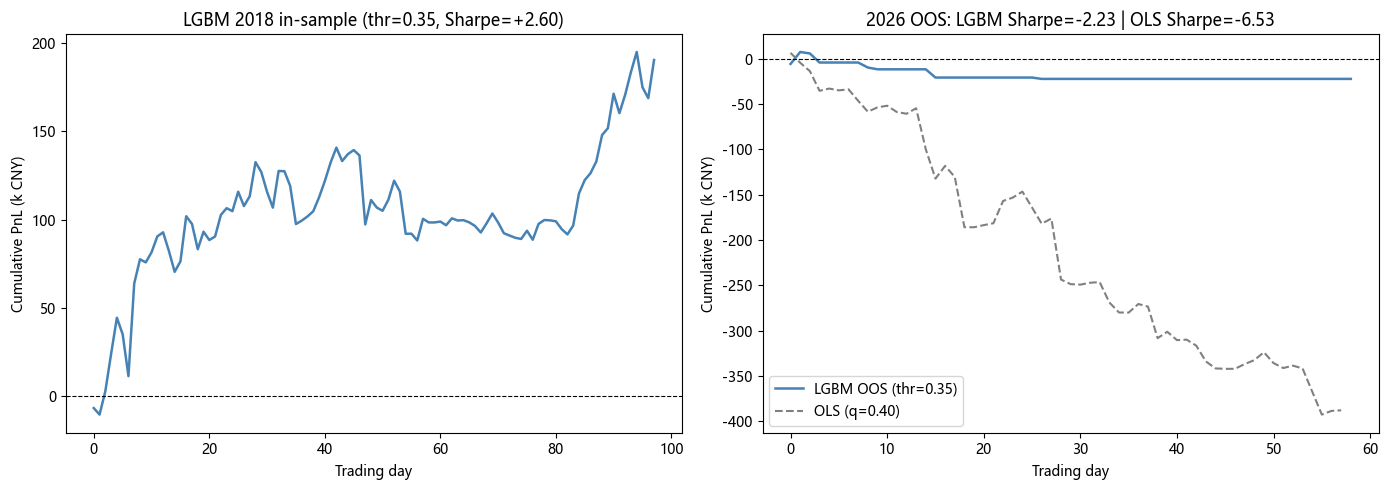

In [29]:
# 8.6  Equity curves: 2018 IS vs 2026 OOS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lgbm_days = sorted(best_res.keys())
axes[0].plot(np.cumsum([best_res[d]['daily_pnl'] for d in lgbm_days]) / 1000,
             color='steelblue', linewidth=1.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title(f'LGBM 2018 in-sample (thr={best_thr}, '
                  f'Sharpe={best_metrics_lgbm["annualized_sharpe"]:+.2f})')
axes[0].set_xlabel('Trading day')
axes[0].set_ylabel('Cumulative PnL (k CNY)')

oos_days     = sorted(oos_res.keys())
ols_oos_days = sorted(d for d in ols_2026_res if d in set(ALL_DAYS_2026))
axes[1].plot(np.cumsum([oos_res[d]['daily_pnl'] for d in oos_days]) / 1000,
             color='steelblue', linewidth=1.8, label=f'LGBM OOS (thr={OOS_THRESHOLD})')
axes[1].plot(np.cumsum([ols_2026_res[d]['daily_pnl'] for d in ols_oos_days]) / 1000,
             color='grey', linewidth=1.5, linestyle='--', label='OLS (q=0.40)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title(f'2026 OOS: LGBM Sharpe={oos_metrics["annualized_sharpe"]:+.2f} | '
                  f'OLS Sharpe={ols_2026_metrics["annualized_sharpe"]:+.2f}')
axes[1].set_xlabel('Trading day')
axes[1].set_ylabel('Cumulative PnL (k CNY)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 9 — OOS Diagnostics: Why 2026 Fails

Only 71 trades / 59 days = 1.2/day in 2026 vs 19.1/day in 2018.  
Hypothesis: P(up) probabilities in 2026 are concentrated near 0.5 → threshold=0.35 rarely fires.  
Possible causes: (A) feature distribution shift, (B) alpha genuinely weaker in 2026, (C) both.

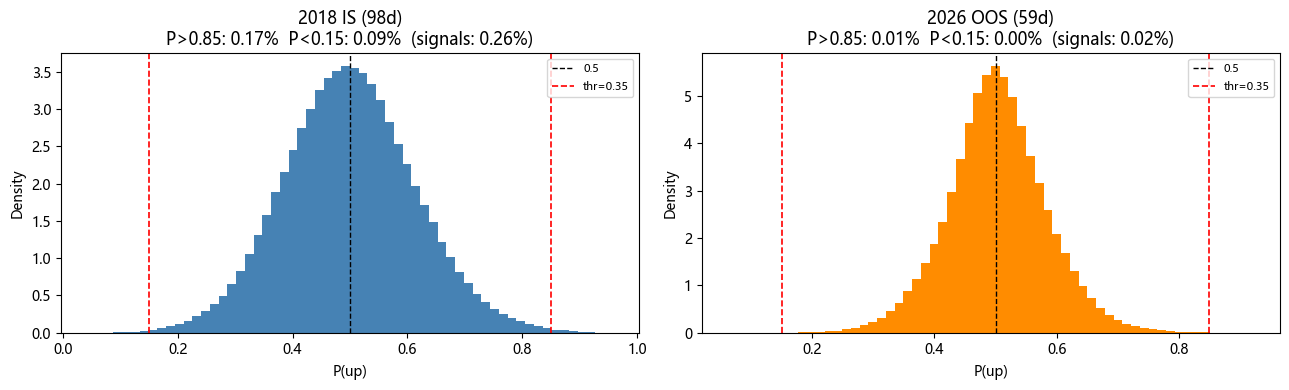

2018 signal rate: 0.258%
2026 signal rate: 0.017%
2018 P(up) std: 0.1141  mean: 0.4992
2026 P(up) std: 0.0803  mean: 0.5028


In [30]:
# 9.1  P(up) distribution: 2018 IS vs 2026 OOS
p18 = all_features.loc[all_features[DAY_COL].isin(LGBM_TEST_DAYS), 'lgbm_prob'].dropna()
p26 = all_features_2026['lgbm_prob'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, probs, label, color in [
    (axes[0], p18, '2018 IS (98d)', 'steelblue'),
    (axes[1], p26, '2026 OOS (59d)', 'darkorange'),
]:
    ax.hist(probs, bins=60, color=color, edgecolor='none', density=True)
    ax.axvline(0.5,        color='black',  linewidth=1.0, linestyle='--', label='0.5')
    ax.axvline(0.5+0.35,   color='red',    linewidth=1.2, linestyle='--', label='thr=0.35')
    ax.axvline(0.5-0.35,   color='red',    linewidth=1.2, linestyle='--')
    pct_above = (probs > 0.85).mean()
    pct_below = (probs < 0.15).mean()
    ax.set_title(f'{label}\nP>0.85: {pct_above:.2%}  P<0.15: {pct_below:.2%}  (signals: {pct_above+pct_below:.2%})')
    ax.set_xlabel('P(up)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'2018 signal rate: {((p18>0.85)|(p18<0.15)).mean():.3%}')
print(f'2026 signal rate: {((p26>0.85)|(p26<0.15)).mean():.3%}')
print(f'2018 P(up) std: {p18.std():.4f}  mean: {p18.mean():.4f}')
print(f'2026 P(up) std: {p26.std():.4f}  mean: {p26.mean():.4f}')

In [31]:
# 9.2  Feature distribution comparison: 2018 vs 2026
key_feats = ['VOI_t0', 'OIR_t0', 'MPB_t0', 'LDiff_t0', 'CostToTrade']
rows = []
for f in key_feats:
    v18 = all_features[f].dropna()
    v26 = all_features_2026[f].dropna()
    rows.append({
        'Feature': f,
        '2018 mean': v18.mean(), '2018 std': v18.std(),
        '2026 mean': v26.mean(), '2026 std': v26.std(),
        'mean shift': (v26.mean() - v18.mean()) / v18.std(),
        'std ratio':  v26.std() / v18.std(),
    })
feat_cmp = pd.DataFrame(rows).set_index('Feature')
print('Feature distribution comparison (2018 vs 2026):')
print(feat_cmp.to_string(float_format='{:+.3f}'.format))
print('\nmean shift: z-score of distribution center shift')
print('std ratio: 2026_std / 2018_std  (>1 = more volatile features in 2026)')

Feature distribution comparison (2018 vs 2026):
             2018 mean  2018 std  2026 mean  2026 std  mean shift  std ratio
Feature                                                                     
VOI_t0          -0.022    +4.509     +0.018   +12.299      +0.009     +2.728
OIR_t0          +0.011    +0.840     -0.019    +1.377      -0.036     +1.638
MPB_t0          -0.009    +0.673     +0.003    +0.548      +0.017     +0.813
LDiff_t0        +0.020    +0.526     -0.001    +0.293      -0.040     +0.558
CostToTrade     +0.000    +0.000     +0.000    +0.000      -1.148     +0.400

mean shift: z-score of distribution center shift
std ratio: 2026_std / 2018_std  (>1 = more volatile features in 2026)


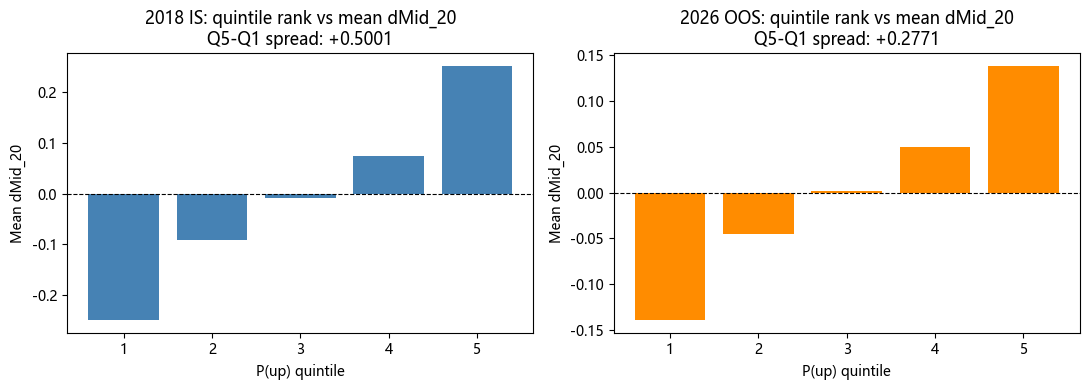

2018 quintile means:
prob_q
1   -0.24914
2   -0.09241
3   -0.00853
4   +0.07445
5   +0.25096

2026 quintile means:
prob_q
1   -0.13902
2   -0.04513
3   +0.00138
4   +0.05028
5   +0.13804


In [32]:
# 9.3  Quintile conditional return: 2026 (does the P(up) rank still predict direction?)
test26 = all_features_2026.dropna(subset=['lgbm_prob', TARGET_CONT]).copy()
test26['prob_q'] = pd.qcut(test26['lgbm_prob'], 5, labels=False) + 1
q_means_26 = test26.groupby('prob_q')[TARGET_CONT].mean()

test18 = all_features.loc[all_features[DAY_COL].isin(LGBM_TEST_DAYS)].dropna(
    subset=['lgbm_prob', TARGET_CONT]).copy()
test18['prob_q'] = pd.qcut(test18['lgbm_prob'], 5, labels=False) + 1
q_means_18 = test18.groupby('prob_q')[TARGET_CONT].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, qm, label, color in [
    (axes[0], q_means_18, '2018 IS', 'steelblue'),
    (axes[1], q_means_26, '2026 OOS', 'darkorange'),
]:
    ax.bar(qm.index, qm.values, color=color)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    spread = qm.iloc[-1] - qm.iloc[0]
    ax.set_title(f'{label}: quintile rank vs mean dMid_20\nQ5-Q1 spread: {spread:+.4f}')
    ax.set_xlabel('P(up) quintile')
    ax.set_ylabel('Mean dMid_20')

plt.tight_layout()
plt.show()

print('2018 quintile means:')
print(q_means_18.to_string(float_format='{:+.5f}'.format))
print('\n2026 quintile means:')
print(q_means_26.to_string(float_format='{:+.5f}'.format))

In [33]:
# 9.4  2026-only threshold sweep (diagnostic only -- not for live use)
# Tests if a lower threshold would activate more trades and whether alpha exists at all
oos_sweep_rows = []
THRESHOLDS_DIAG = [0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]

for thr in THRESHOLDS_DIAG:
    res = run_lgbm_backtest(all_features_2026, 'lgbm_signal', ALL_DAYS_2026, thr)
    m   = compute_performance_metrics(
        res, trading_days=ALL_DAYS_2026, verbose=False, output_dir=None
    )
    oos_sweep_rows.append({
        'threshold': thr, 'P_min': round(0.5 + thr, 2),
        'sharpe': m['annualized_sharpe'], 'mean_pnl': m['mean_daily_pnl'],
        'win_rate': m['win_rate_per_trade'], 'n_trades': m['n_trades'],
        't_stat': m['t_stat'],
    })
    print(f'thr={thr:.2f} P>{0.5+thr:.2f} | Sharpe={m["annualized_sharpe"]:+.3f} '
          f'| PnL={m["mean_daily_pnl"]:+,.0f} | trades={m["n_trades"]:,} '
          f'| win={m["win_rate_per_trade"]*100:.1f}%')

oos_sweep_df = pd.DataFrame(oos_sweep_rows)
print('\n[diagnostic only — threshold chosen on 2026 data is in-sample]')

thr=0.02 P>0.52 | Sharpe=-182.516 | PnL=-2,994,483 | trades=415,472 | win=1.5%
thr=0.05 P>0.55 | Sharpe=-207.476 | PnL=-1,693,771 | trades=251,855 | win=3.4%
thr=0.08 P>0.58 | Sharpe=-115.128 | PnL=-915,293 | trades=147,113 | win=6.6%
thr=0.10 P>0.60 | Sharpe=-76.050 | PnL=-595,900 | trades=101,284 | win=9.7%
thr=0.15 P>0.65 | Sharpe=-28.778 | PnL=-173,082 | trades=34,711 | win=20.2%
thr=0.20 P>0.70 | Sharpe=-13.912 | PnL=-45,496 | trades=10,330 | win=29.1%
thr=0.25 P>0.75 | Sharpe=-7.546 | PnL=-10,480 | trades=2,558 | win=36.2%
thr=0.30 P>0.80 | Sharpe=-3.584 | PnL=-2,055 | trades=502 | win=39.6%
thr=0.35 P>0.85 | Sharpe=-2.235 | PnL=-379 | trades=71 | win=40.8%

[diagnostic only — threshold chosen on 2026 data is in-sample]
